In [1]:
import numpy as np
import sys 
import sys
sys.path.append('../scripts')
import assembly_tree as at
sys.path.append('../scripts')
import mcmc 
import networkx as nx 
import matplotlib.pyplot as plt 
import numpy as np 
import json
import os
import treelib
import importlib
import copy
#import pandas as pd

importlib.reload(at)

<module 'assembly_tree' from '/Users/glover.co/Documents/laszlo/NetDesign/notebooks/../scripts/assembly_tree.py'>

In [2]:
def encode_tree(node,Tree):
    # Base case: if the node is a leaf, return just the count
    if not node.is_leaf(Tree) or len(Tree.children(node.identifier)) == 0:
        return [len(node.data.nodes)]
    
    # Otherwise, encode the subtree for each child
    encoded_children = [encode_tree(child,Tree) for child in sorted(Tree.children(node.identifier),key = lambda v: (-Tree.depth(v),-len(v.data.nodes)))]
    
    return [len(node.data.nodes)] + [encoded_children]

In [3]:
protein_human_path = '/Users/glover.co/Documents/laszlo/NetDesign/data/proteins/human'


In [4]:
target = nx.read_edgelist(f'{protein_human_path}/edgefiles/CPX-1919.edge', nodetype=int)
X = np.loadtxt(f'{protein_human_path}/Xfiles/X_CPX-1919.txt')
O = at.extract_O(target, X)
capacity = at.extract_deg_cap(target, X).reshape(-1)

In [5]:
initial_tree = mcmc.AssemblyTree(target,X,O,capacity)

In [6]:
initial_tree.update_tree(dist=[.25,.25,0,0,.25,.25])

False

In [132]:
initial_tree.Tree.show()

0
├── 1
│   ├── 14
│   ├── 15
│   └── 16
├── 2
│   ├── 11
│   └── 12
├── 3
├── 4
├── 5
├── 6
├── 7
├── 8
├── 9
└── 10



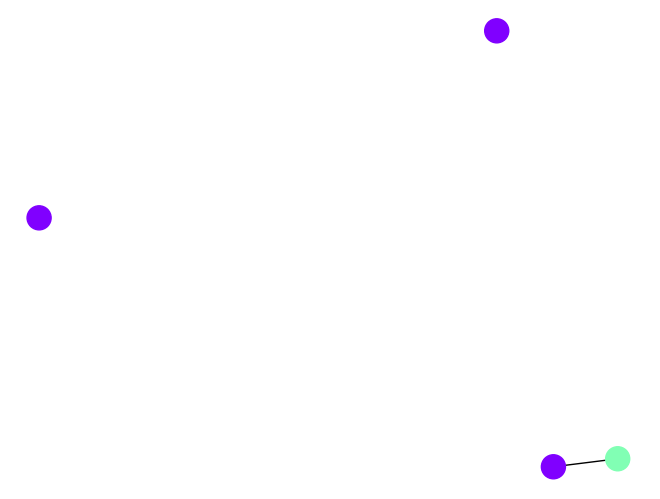

In [137]:
at.draw_network(initial_tree.Tree.get_node(1).data.subgraph[0],initial_tree.X)

In [136]:
initial_tree.Tree.get_node(2).data.p

[np.float64(1.0)]

In [11]:
initial_tree.remove_branching_point(8)

In [16]:
initial_tree.Tree.root

0

In [7]:
Tis = np.ones(1000)
c1q = mcmc.DesignMCMC(initial_tree)


/Users/glover.co/Documents/laszlo/NetDesign/notebooks/../scripts/mcmc.py:582: RuntimeWarning: divide by zero encountered in log
  self.cur_prob = copy.deepcopy(np.log(sum(self.cur_T.Tree.get_node(0).data.p)))


In [11]:
tree_list = [copy.deepcopy(initial_tree)]
uniq_tree_list = [copy.deepcopy(initial_tree)]
for i in range(1000):
    c1q.run_mcmc(1,[1],dist=[.25,.25,0,0,.25,.25],prior='uniform')
    tree_list.append(copy.deepcopy(c1q.cur_T))
    found = False
    for tree in uniq_tree_list:
        if encode_tree(tree.Tree.get_node(0),tree.Tree) == encode_tree(c1q.cur_T.Tree.get_node(0),c1q.cur_T.Tree):
            found= True
            break
    if not found:
        uniq_tree_list.append(copy.deepcopy(c1q.cur_T))

curp,posterior -688.4729428052196 -688.4729428052196
ac 1.0
4
bestlog -688.4729428052196
curp,posterior -688.4729428052196 -688.4729428052196
ac 1.0
5
bestlog -688.4729428052196
curp,posterior -688.4729428052196 -688.4729428052196
ac 1.0
6
bestlog -688.4729428052196
curp,posterior -688.4729428052196 -688.4729428052196
ac 1.0
7
bestlog -688.4729428052196
curp,posterior -688.4729428052196 -688.4729428052196
ac 1.0
8
bestlog -688.4729428052196
curp,posterior -688.4729428052196 -688.4729428052196
ac 1.0
9
bestlog -688.4729428052196
curp,posterior -688.4729428052196 -688.4729428052196
ac 1.0
10
bestlog -688.4729428052196
curp,posterior -688.4729428052196 -688.4729428052196
ac 1.0
11
bestlog -688.4729428052196
curp,posterior -688.4729428052196 -688.4729428052196
ac 1.0
12
bestlog -688.4729428052196
curp,posterior -688.4729428052196 -688.4729428052196
ac 1.0
13
bestlog -688.4729428052196
curp,posterior -688.4729428052196 -688.4729428052196
ac 1.0
14
bestlog -688.4729428052196
curp,posterior -

In [7]:
len(tree_dict.keys())

28

In [13]:
depths = []
uniq_depths = []
for tree in tree_list:
    depths.append(tree.Tree.depth())
for tree in uniq_tree_list:
    uniq_depths.append(tree.Tree.depth())

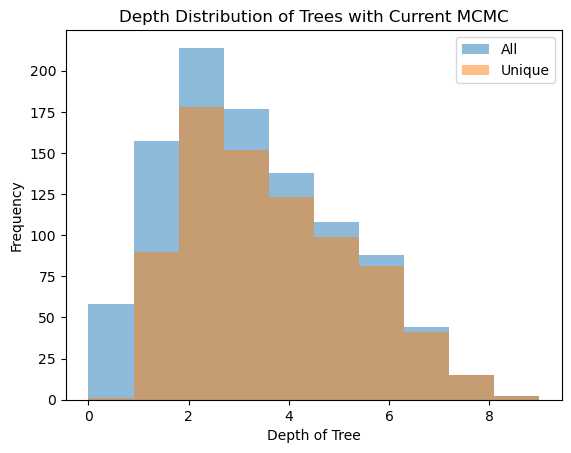

In [15]:
plt.hist(depths,label='All',alpha=0.5)
plt.hist(uniq_depths,label='Unique',alpha=0.5)
plt.xlabel('Depth of Tree')
plt.ylabel('Frequency')
plt.title('Depth Distribution of Trees with Current MCMC')
plt.legend()
plt.show()

In [13]:
c1q.cur_T.split(0)

In [16]:
c1q.cur_T.add_branching_point(0)

In [21]:
c1q.cur_T.add_branching_point(0)

In [41]:
c1q.cur_T.Tree.children(18)

[Node(tag=8, identifier=8, data=<mcmc.AssemblyNode object at 0x174f963c0>),
 Node(tag=9, identifier=9, data=<mcmc.AssemblyNode object at 0x174f96450>),
 Node(tag=13, identifier=13, data=<mcmc.AssemblyNode object at 0x174f96690>),
 Node(tag=10, identifier=10, data=<mcmc.AssemblyNode object at 0x174f964e0>),
 Node(tag=1, identifier=1, data=<mcmc.AssemblyNode object at 0x174f95fd0>),
 Node(tag=2, identifier=2, data=<mcmc.AssemblyNode object at 0x174f96060>)]

In [23]:
nodes = c1q.cur_T.Tree.nodes    

In [36]:
def compare_trees(tree1, tree2):
    tree1_dict = {}
    tree2_dict = {}
    depth1 = tree1.Tree.depth()
    depth2 = tree2.Tree.depth()
    if depth1 != depth2:
        return False
    next_children1 = []
    cur_level1 = [tree1.Tree.root]
    next_children2 = []
    cur_level2 = [tree2.Tree.root]
    for i in range(depth1):
        tree1_dict[i] = cur_level1
        tree2_dict[i] = cur_level2
        # Get number of children for each node at depth
        for j in range(len(cur_level1)):
            children1 = cur_level1[j][1]
            children2 = cur_level2[j][1]
            if len(children1) != len(children2):
                return False
            # Sort children by number of children
            children1.sort(key=lambda x: len(tree1.Tree.get_node(x).data.nodes))
            children2.sort(key=lambda x: len(tree2.Tree.get_node(x).data.nodes))
            next_children1.extend([(tree1.Tree.get_node(children1[k]), tree1.Tree.get_node(children1[k]).data.nodes) for k in range(len(children1))])
            next_children2.extend([(tree2.Tree.get_node(children2[k]), tree2.Tree.get_node(children2[k]).data.nodes) for k in range(len(children2))])
        cur_level1 = next_children1
        cur_level2 = next_children2
        next_children1 = []
        next_children2 = []
    return True

In [37]:
c1q.cur_T.Tree.show()

0
├── 3
├── 4
├── 5
├── 7
├── 11
├── 12
├── 14
├── 15
├── 17
├── 18
│   ├── 1
│   ├── 2
│   ├── 8
│   ├── 9
│   ├── 10
│   └── 13
└── 19
    ├── 6
    └── 16



In [38]:
c1q2 = copy.deepcopy(c1q)

In [39]:
compare_trees(c1q.cur_T, c1q2.cur_T)

TypeError: 'int' object is not subscriptable

In [80]:
def encode_tree(node,Tree):
    # Base case: if the node is a leaf, return just the count
    if not node.is_leaf(Tree) or len(Tree.children(node.identifier)) == 0:
        return [len(node.data.nodes)]
    
    # Otherwise, encode the subtree for each child
    encoded_children = [encode_tree(child,Tree) for child in sorted(Tree.children(node.identifier),key = lambda v: (-Tree.depth(v),-len(v.data.nodes)))]
    
    return [len(node.data.nodes)] + [encoded_children]



In [81]:
encode_tree(initial_tree.Tree.get_node(0),initial_tree.Tree)

[18, [[10, [[5], [2], [1], [1], [1]]], [5], [2], [1]]]

In [47]:
initial_tree = mcmc.AssemblyTree(target,X,O,capacity)

In [62]:
initial_tree.update_tree(dist=[.25,.25,0,0,.25,.25])

In [63]:
initial_tree.Tree.show()

0
├── 1
├── 4
├── 6
└── 9
    ├── 2
    ├── 3
    ├── 5
    ├── 7
    └── 8



In [66]:
initial_tree.Tree.get_node(0).data.nodes

[16, 6, 2, 3, 4, 1, 8, 9, 10, 15, 13, 14, 0, 7, 11, 12, 17, 5]

In [68]:
sorted(initial_tree.Tree.children(0),key= lambda v: (-initial_tree.Tree.depth(v),-len(initial_tree.Tree.get_node(v).data.nodes)))

AttributeError: 'NoneType' object has no attribute 'data'

In [70]:
children = initial_tree.Tree.children(0)

In [72]:
v =children[0]

In [73]:
initial_tree.Tree.depth(v)

1

In [77]:
v.data.nodes

[16, 6, 2, 3, 4]

In [75]:
initial_tree.Tree.get_node(v)

In [76]:
v

Node(tag=1, identifier=1, data=<mcmc.AssemblyNode object at 0x174f94170>)